# MODULE 1 — Data Loading & Preprocessing
**Goal:** Load BCI IV-2a, preprocess, visualise raw vs filtered signals, verify shapes.

✅ **Pass criterion:** All 9 subjects loaded, shape `(N, 22, 1000)`, z-score μ≈0 σ≈1

In [1]:
!pip install numpy scipy scikit-learn matplotlib moabb mne -q

In [2]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, pickle
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

FS   = 250   # Hz
SEED = 42
np.random.seed(SEED)

BANDS = [
    (1,4),(4,8),(8,12),(12,16),(16,20),
    (20,24),(24,28),(28,32),(32,35),(35,38)
]
BAND_NAMES = [f'{lo}-{hi}Hz' for lo,hi in BANDS]

print('Libraries loaded.')

Libraries loaded.


## 1.1 Load Dataset

In [3]:
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)

print('Downloading / loading BCI IV-2a (9 subjects)...')
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))

# Paper: 22 channels, 1000 time-points (4s @ 250 Hz)
X_raw = X_raw[:, :22, :1000].astype(np.float32)

le        = LabelEncoder()
y_enc     = le.fit_transform(y_raw).astype(np.int64)  # 0-3
subjects  = np.array([str(s) for s in meta['subject'].values])
sessions  = np.array([str(s) for s in meta['session'].values])

# Identify session names
sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]   # S0=calib/GAN, S1=test

print(f'\nX shape   : {X_raw.shape}  (trials, channels, time)')
print(f'Classes   : {le.classes_}  →  0-3')
print(f'Subjects  : {np.unique(subjects)}')
print(f'Sessions  : {sess_vals}  → calib={S0!r}  test={S1!r}')
print(f'\nTrials per subject × session:')
for s in sorted(np.unique(subjects)):
    n0 = ((subjects==s)&(sessions==S0)).sum()
    n1 = ((subjects==s)&(sessions==S1)).sum()
    print(f'  subj {s}: session-0={n0}  session-1={n1}')

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events



X shape   : (5184, 22, 1000)  (trials, channels, time)
Classes   : ['feet' 'left_hand' 'right_hand' 'tongue']  →  0-3
Subjects  : ['1' '2' '3' '4' '5' '6' '7' '8' '9']
Sessions  : ['0train', '1test']  → calib='0train'  test='1test'

Trials per subject × session:
  subj 1: session-0=288  session-1=288
  subj 2: session-0=288  session-1=288
  subj 3: session-0=288  session-1=288
  subj 4: session-0=288  session-1=288
  subj 5: session-0=288  session-1=288
  subj 6: session-0=288  session-1=288
  subj 7: session-0=288  session-1=288
  subj 8: session-0=288  session-1=288
  subj 9: session-0=288  session-1=288


## 1.2 Preprocessing Functions

In [4]:
def bandpass(X, lo, hi, fs=FS, order=5):
    """5th-order Butterworth bandpass (paper Sec. 2.2)"""
    nyq  = fs / 2
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore(X_tr, X_other):
    """
    Z-score normalisation (paper Eq. 1).
    Stats computed from X_tr only — applied to X_other.
    """
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    std = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr - mu) / std, (X_other - mu) / std

def filter_bank(X):
    """Apply all 10 sub-bands, return list of 10 arrays same shape as X."""
    return [bandpass(X, lo, hi) for lo,hi in BANDS]

print('Preprocessing functions defined.')

Preprocessing functions defined.


## 1.3 Visualise: Raw vs Broadband Filtered Signal

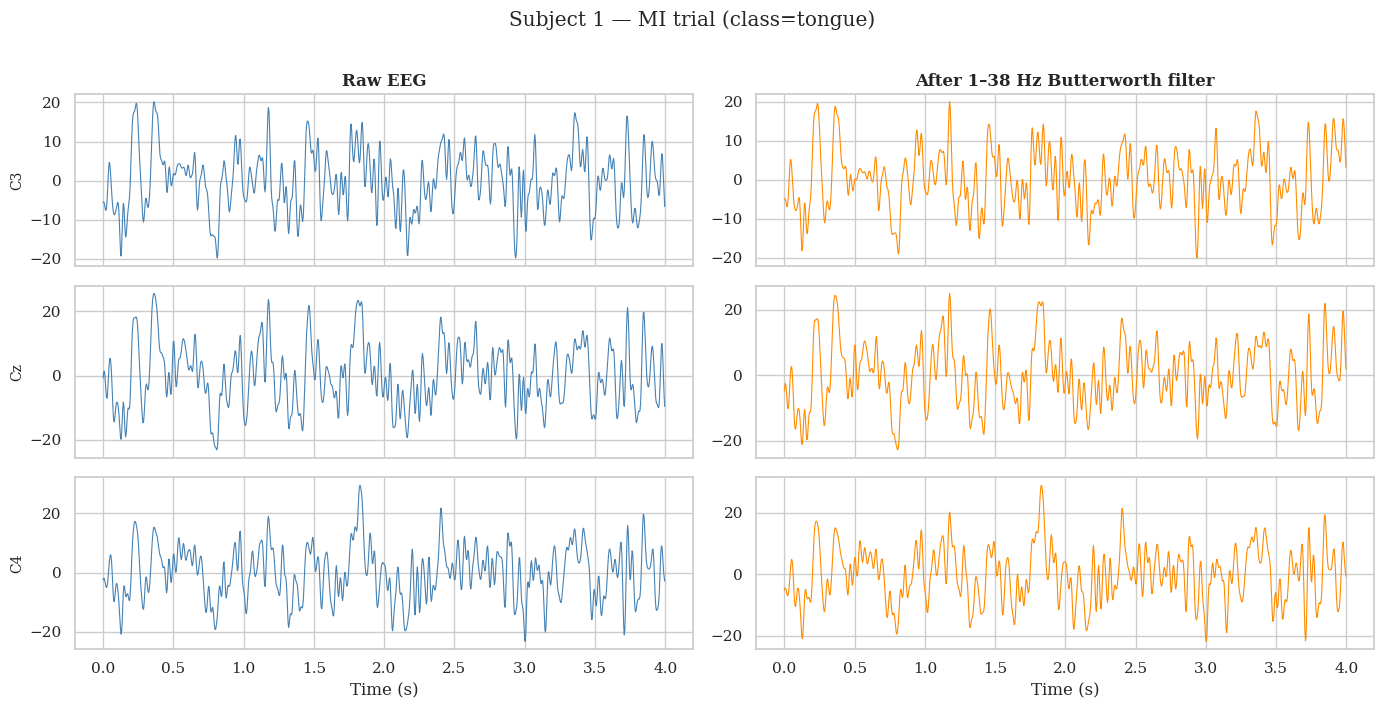

Saved m1_raw_vs_filtered.png


In [5]:
# Pick subject 1, first trial
trial_idx  = np.where((subjects=='1') & (sessions==S0))[0][0]
trial_raw  = X_raw[trial_idx]           # (22, 1000)
trial_bp   = bandpass(trial_raw[np.newaxis], 1, 38)[0]  # broadband

time = np.arange(1000) / FS
MI_CHANNELS = [7, 9, 11]   # C3, Cz, C4  (approx indices in 22-ch layout)
CH_NAMES    = ['C3','Cz','C4']

fig, axes = plt.subplots(3, 2, figsize=(14, 7), sharex=True)
for row, (ch, name) in enumerate(zip(MI_CHANNELS, CH_NAMES)):
    axes[row,0].plot(time, trial_raw[ch], color='steelblue', lw=0.8)
    axes[row,0].set_ylabel(name, fontsize=10)
    axes[row,1].plot(time, trial_bp[ch],  color='darkorange', lw=0.8)

axes[0,0].set_title('Raw EEG', fontweight='bold')
axes[0,1].set_title('After 1–38 Hz Butterworth filter', fontweight='bold')
for ax in axes[-1]: ax.set_xlabel('Time (s)')
plt.suptitle(f'Subject 1 — MI trial (class={le.classes_[y_enc[trial_idx]]})', y=1.01)
plt.tight_layout()
plt.savefig('m1_raw_vs_filtered.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved m1_raw_vs_filtered.png')

## 1.4 Visualise: All 10 Filter Bank Sub-bands

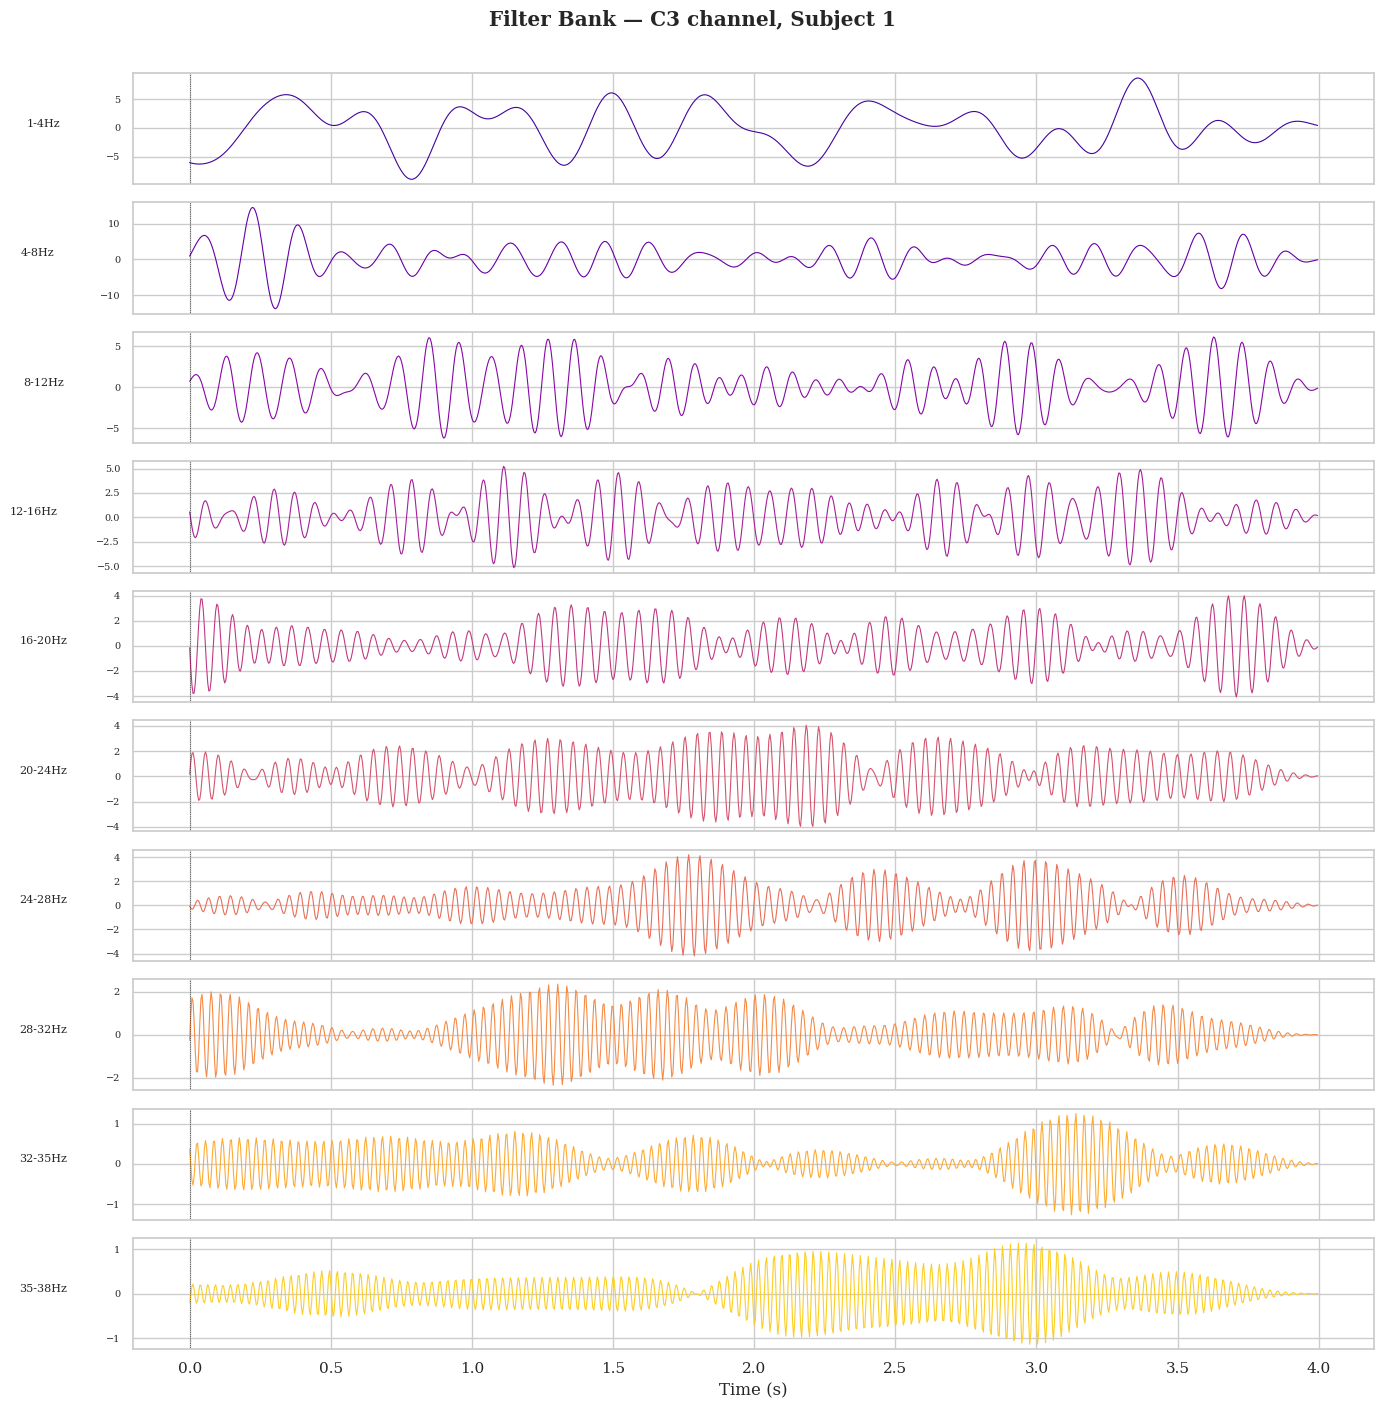

Saved m1_filter_bank.png


In [6]:
fb_bands = filter_bank(trial_bp[np.newaxis])   # list of 10 × (1, 22, 1000)
ch = MI_CHANNELS[0]   # C3

fig, axes = plt.subplots(10, 1, figsize=(14, 14), sharex=True)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, 10))

for i, (ax, band_sig, bname, c) in enumerate(
        zip(axes, fb_bands, BAND_NAMES, colors)):
    ax.plot(time, band_sig[0, ch], color=c, lw=0.8)
    ax.set_ylabel(bname, fontsize=8, rotation=0, labelpad=45)
    ax.yaxis.set_tick_params(labelsize=7)
    ax.axvline(0, color='k', ls=':', lw=0.5)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Filter Bank — C3 channel, Subject 1', fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('m1_filter_bank.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved m1_filter_bank.png')

## 1.5 Verify Z-score Normalisation

After z-score (training set):
  mean  = -0.0000   (want ≈ 0)
  std   = 1.0000  (want ≈ 1)


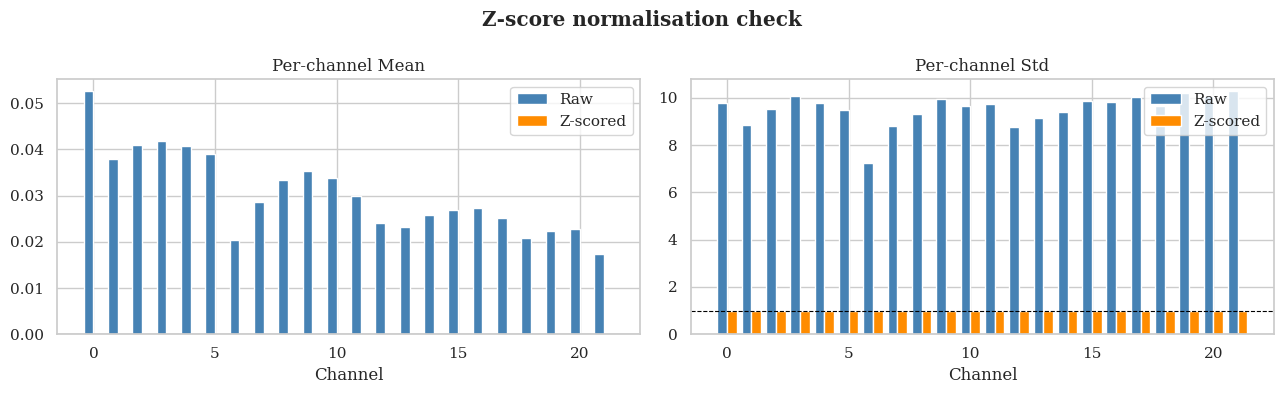


✅  MODULE 1 PASS — data loaded and preprocessed correctly


In [7]:
# Use subject 1 as test, rest as train
m_tr = subjects != '1'
m_te = (subjects == '1') & (sessions == S1)

X_tr_n, X_te_n = zscore(X_raw[m_tr], X_raw[m_te])

tr_mu  = X_tr_n.mean(axis=(0,2)).mean()
tr_std = X_tr_n.std (axis=(0,2)).mean()

print('After z-score (training set):')
print(f'  mean  = {tr_mu:.4f}   (want ≈ 0)')
print(f'  std   = {tr_std:.4f}  (want ≈ 1)')

# Plot per-channel mean and std before/after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

raw_mu_ch  = X_raw[m_tr].mean(axis=(0,2))
norm_mu_ch = X_tr_n.mean(axis=(0,2))
raw_std_ch = X_raw[m_tr].std(axis=(0,2))
norm_std_ch= X_tr_n.std(axis=(0,2))

ch_idx = np.arange(22)
axes[0].bar(ch_idx-0.2, raw_mu_ch,  0.4, label='Raw',       color='steelblue')
axes[0].bar(ch_idx+0.2, norm_mu_ch, 0.4, label='Z-scored', color='darkorange')
axes[0].axhline(0, color='k', lw=0.8); axes[0].set_title('Per-channel Mean')
axes[0].set_xlabel('Channel'); axes[0].legend()

axes[1].bar(ch_idx-0.2, raw_std_ch,  0.4, label='Raw',       color='steelblue')
axes[1].bar(ch_idx+0.2, norm_std_ch, 0.4, label='Z-scored', color='darkorange')
axes[1].axhline(1, color='k', lw=0.8, ls='--'); axes[1].set_title('Per-channel Std')
axes[1].set_xlabel('Channel'); axes[1].legend()

plt.suptitle('Z-score normalisation check', fontweight='bold')
plt.tight_layout()
plt.savefig('m1_zscore_check.png', dpi=120, bbox_inches='tight')
plt.show()

# ── PASS / FAIL ───────────────────────────────────────────────────────────
assert abs(tr_mu)  < 0.01, f'FAIL: mean={tr_mu:.4f}'
assert abs(tr_std - 1.0) < 0.1, f'FAIL: std={tr_std:.4f}'
print('\n✅  MODULE 1 PASS — data loaded and preprocessed correctly')

## 1.6 Save Data for Next Modules

In [8]:
data_bundle = dict(
    X_raw   = X_raw,
    y_enc   = y_enc,
    subjects= subjects,
    sessions= sessions,
    S0      = S0,
    S1      = S1,
    classes = le.classes_,
    BANDS   = BANDS,
    FS      = FS,
)
with open('eeg_data_bundle.pkl', 'wb') as f:
    pickle.dump(data_bundle, f)

print('Saved eeg_data_bundle.pkl')
print(f'  X_raw   : {X_raw.shape}')
print(f'  Subjects: {np.unique(subjects)}')
print(f'  Sessions: {S0!r} (calib)  {S1!r} (test)')

Saved eeg_data_bundle.pkl
  X_raw   : (5184, 22, 1000)
  Subjects: ['1' '2' '3' '4' '5' '6' '7' '8' '9']
  Sessions: '0train' (calib)  '1test' (test)
